<a href="https://colab.research.google.com/github/giuliacenni-dns/MindCare/blob/main/Giulia%20Cenni%20MindReading_Report1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install nilearn

# Structural Imaging Assignment
For this assignment, you will work with MRI data from approximately 900 participants from the Amsterdam Open MRI Collection (AOMIC). The dataset is described in detail here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. Sci Data 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

FreeSurfer preprocessing has already been completed. You will receive:

- A CSV table with FreeSurfer-derived measures (cortical thickness, surface area, curvature, subcortical volumes)
- A table with demographic information (age, biological sex)
- A data dictionary explaining each column

### Your Task
Build a classification model to predict biological sex from brain structure. Specifically:
- Identify which brain measures contribute most to classification
- Quantify effect sizes and classification performance
- Characterise the degree of overlap between groups
- Discuss what your findings reveal about sex differences in brain structure

For this assignment, you will use logistic regression to classify sex from brain structure. Logistic regression is appropriate for binary classification, computationally efficient, and provides interpretable coefficients indicating which features contribute most to classification.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas. You can also refer to the notebooks from the lab practicals, especially Lab 4 on predicting age from brain structure.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [19]:
# ------- Leave this code as is -----------
### Loading the data

import os
import pandas as pd
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Download required data files
for url, name in zip([
        "https://www.dropbox.com/scl/fi/kssezv0bic0asdlug4vtn/demographic_data.csv?rlkey=rn3zs0ggjcprkcmec54uy6s5s&dl=1",
        "https://www.dropbox.com/scl/fi/ypa33lzz0mlx8cswz9nej/morphology_data.csv?rlkey=awl906mvp10pofv6hjilfzl8e&dl=1"
    ],
    [
        "demographic_data.csv",
        "morphology_data.csv"
    ]):

    download_file(url, name)

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

demographic_data.csv already exists, skipping download.
morphology_data.csv already exists, skipping download.


### Part 1: Code Implementation (30%)
Implement your proposed analysis with clear structure

Include comments or markdown cells explaining:
- What each code section does
- Why you made specific methodological choices (e.g., "Using 5-fold CV to balance bias-variance tradeoff")
- Any assumptions or decisions about data handling
- Ensure code runs without errors

You can use the code below as a starting point.

### Data loading and preprocessing

The demographic and morphology datasets are loaded and merged on `participant_id` to ensure alignment between participant information and FreeSurfer-derived structural brain measures.

All available structural predictors are included in the main analysis, including cortical thickness, cortical surface area, curvature, and subcortical measures. The variables `participant_id`, `sex`, and `age` are excluded from the predictor set. Biological sex is recoded as a binary variable (0 = female, 1 = male).

Estimated total intracranial volume (eTIV) is also excluded from the main analysis to avoid capturing global brain size effects. It will be included later in a sensitivity analysis to assess whether classification performance and feature importance remain after accounting for overall brain size.

In [20]:
# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")


# Feature selection

# Extracting predictor matrix X and target vector y
# I exclude participant_id, age, and sex so that the model uses only structural brain measures

feature_cols = [
    col for col in data_df.columns
    if col not in ["participant_id", "age", "sex"]
    and "tiv" not in col.lower()
    and "intracranial" not in col.lower()
]
X = data_df[feature_cols]
y = (data_df["sex"] == "male").astype(int) # Binary encoding: female = 0, male = 1

# Checking the shapes of X and y
print(f"Number of features: {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nClass distribution:")
print(y.value_counts())


Number of features: 245
X shape: (928, 245)
y shape: (928,)

Class distribution:
sex
0    483
1    445
Name: count, dtype: int64


### Train-test split

The dataset is divided into training (80%) and test (20%) sets using stratified sampling. Stratification ensures that the proportion of biological sexes is preserved in both subsets, providing a fair basis for model training and evaluation on unseen data.

In [21]:
# Train-test split (STRATIFIED)

# Splitting the data into training and test sets for the final validation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))

print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))


Training set class balance:
sex
0    0.520216
1    0.479784
Name: proportion, dtype: float64

Test set class balance:
sex
0    0.521505
1    0.478495
Name: proportion, dtype: float64


### Model specification

A regularized logistic regression model is used for classification. Predictors are standardized within a scikit-learn pipeline so that scaling is fitted only on the training folds during cross-validation, preventing information leakage. L2 regularization is applied to improve coefficient stability and reduce overfitting, given the high dimensionality and potential collinearity among structural brain features.

In [22]:
# Defining the logistic regression model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ))
])

### Cross-validation and hyperparameter tuning

A stratified 5-fold cross-validation procedure is used to tune the regularization strength (`C`) of the logistic regression model. Stratification preserves class proportions across folds, and 5-fold cross-validation provides a reasonable balance between variance and computational efficiency. This procedure is especially appropriate given the moderate sample size and the relatively large number of structural predictors.

### Model evaluation metric

The primary metric used for model tuning and evaluation is the area under the ROC curve (ROC–AUC). This metric evaluates the model’s ability to discriminate between classes across all possible classification thresholds.

Balanced accuracy and confusion matrices are additionally reported to provide interpretable performance at a fixed classification threshold.

In [23]:
# Setting up 5-fold cross-validation for parameter tuning

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Regularization strength
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with stratified 5-fold cross-validation using ROC-AUC
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Best hyperparameters from grid search
best_params = grid_search.best_params_

print(f"Best hyperparameters: {best_params}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

Best hyperparameters: {'model__C': 0.1}
Best cross-validated ROC-AUC: 0.9587


### Model evaluation on training and test sets

After selecting the best model using cross-validation, the model is evaluated on both the training and test sets. Training performance is reported for comparison, while test set performance provides the primary estimate of generalization to unseen data.

In [24]:
# Training set evaluation (for comparison; main results are from test set)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score
)

best_model = grid_search.best_estimator_

# Training set evaluation
y_train_pred = best_model.predict(X_train)
# Probability of being classified as male (1), given female = 0 and male = 1
y_train_proba = best_model.predict_proba(X_train)[:, 1]

print("Training set performance (for comparison)")
print("------------------------")
print(classification_report(y_train, y_train_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}")


Training set performance (for comparison)
------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       386
           1       0.97      0.99      0.98       356

    accuracy                           0.98       742
   macro avg       0.98      0.98      0.98       742
weighted avg       0.98      0.98      0.98       742

Confusion Matrix:
[[377   9]
 [  5 351]]
Balanced Accuracy: 0.9813
ROC AUC Score: 0.9991


### Test set evaluation

After selecting the best model using cross-validation, the final model is evaluated on the held-out test set. This provides an unbiased estimate of model performance on unseen data.

Balanced accuracy, ROC–AUC, and confusion matrices are reported to assess classification performance at both threshold-independent and threshold-based levels.

In [25]:
# Test set evaluation
y_test_pred = best_model.predict(X_test)
# Predict probabilities for ROC curve
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest set performance (final model evaluation)")
print("------------------------")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")


Test set performance (final model evaluation)
------------------------
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        97
           1       0.86      0.84      0.85        89

    accuracy                           0.86       186
   macro avg       0.86      0.86      0.86       186
weighted avg       0.86      0.86      0.86       186

Confusion Matrix:
[[85 12]
 [14 75]]
Balanced Accuracy: 0.8595
ROC AUC Score: 0.9292


### Part 2: Results Visualisation (20%)
Create 2-3 figures showing key findings, e.g.:
- Classification performance (e.g., confusion matrix, ROC curve, accuracy with confidence intervals)
- Feature importance or effect sizes (e.g., which regions contribute most)
- Distribution overlap (e.g., histograms or scatter plots showing individual variation)

Include clear figure captions explaining what is shown

Below are some examples to get you started, but please modify or create your own visualisations that best illustrate your findings.

### Classification performance visualisation

The following figures illustrate classification performance on the held-out test set, including threshold-based and threshold-independent evaluation metrics.

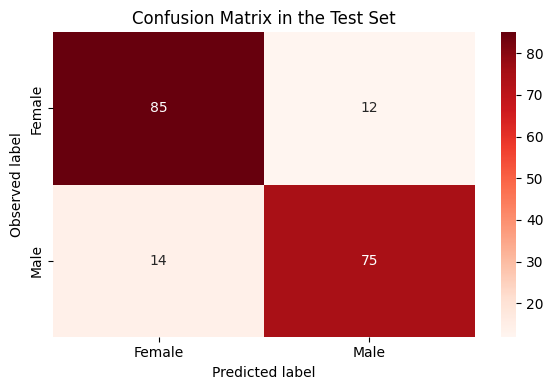

In [26]:
# Plot the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Female", "Male"],
    yticklabels=["Female", "Male"]
)
plt.title("Confusion Matrix in the Test Set")
plt.xlabel("Predicted label")
plt.ylabel("Observed label")
plt.tight_layout()
plt.show()

**Figure 1.** Confusion matrix for the held-out test set. Rows represent observed class labels and columns represent predicted class labels.

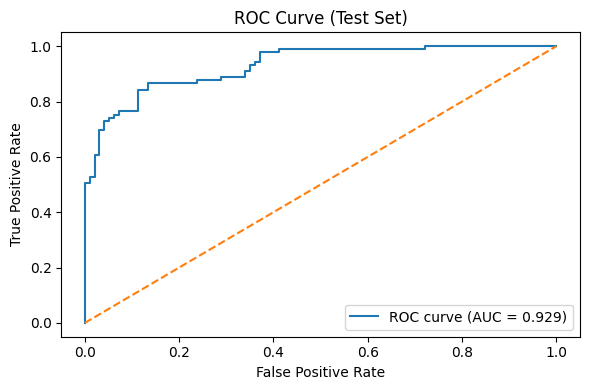

AUC from roc_auc_score: 0.9292250666048881


In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print("AUC from roc_auc_score:", roc_auc_score(y_test, y_test_proba))

**Figure 2.** Receiver operating characteristic (ROC) curve for the held-out test set. The area under the curve (AUC = 0.93) indicates strong discrimination between classes across thresholds.

### Feature importance and effect size analysis

Feature importance is assessed using standardized logistic regression coefficients, which reflect the contribution of each feature within the multivariate model.

Univariate effect sizes (Cohen’s d) are computed to quantify the magnitude of differences between male and female participants for each structural measure. Cohen’s d is computed as the difference between male and female values. Positive values indicate larger values in male participants, whereas negative values indicate larger values in female participants.

Comparing these two measures allows assessment of how multivariate importance relates to univariate group differences.

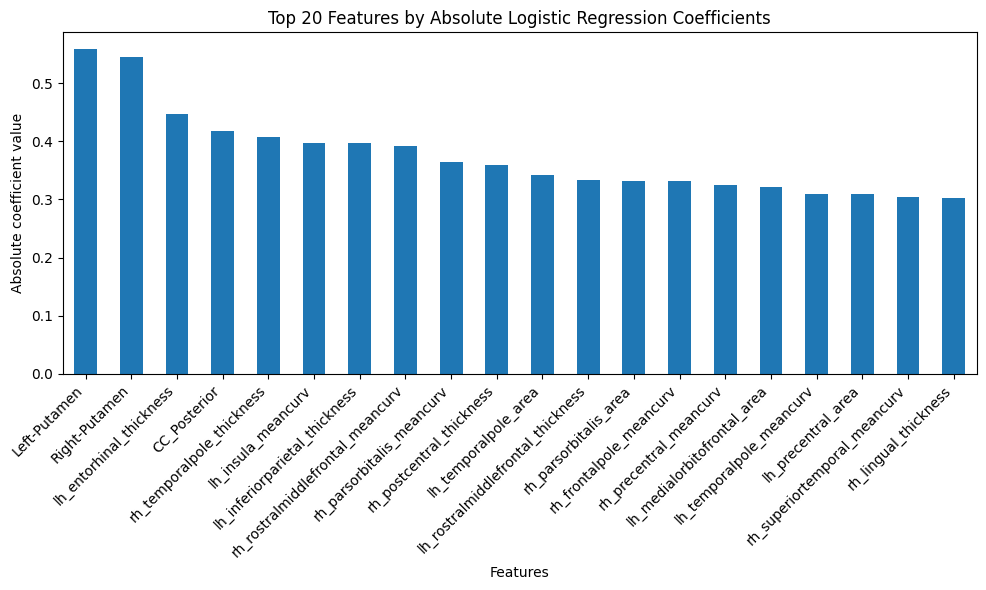

In [28]:
# Extract coefficients from the logistic regression model inside the pipeline
coefficients = best_model.named_steps["model"].coef_[0]

feature_importance = pd.Series(coefficients, index=feature_cols)

top_features = feature_importance.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_features.plot(kind="bar")
plt.title("Top 20 Features by Absolute Logistic Regression Coefficients")
plt.ylabel("Absolute coefficient value")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Figure 3.** Top 20 structural brain features ranked by the absolute magnitude of their standardized logistic regression coefficients. Larger absolute coefficients indicate a stronger conditional contribution to classification within the multivariate model, reflecting the distributed nature of structural differences across regions.

### Univariate effect size analysis

Cohen’s d was computed for each structural feature to quantify the magnitude of differences between male and female participants. The table below shows the top features ranked by absolute effect size.

In [29]:
import numpy as np

# Create a full analysis dataframe for group comparisons
analysis_df = data_df.copy()


def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if pooled_sd == 0:
      return 0

    return (x1.mean() - x2.mean()) / pooled_sd


effect_sizes = []
for col in feature_cols:
    male_vals = analysis_df.loc[analysis_df["sex"] == "male", col]
    female_vals = analysis_df.loc[analysis_df["sex"] == "female", col]
    d = cohens_d(male_vals, female_vals)
    effect_sizes.append({"feature": col, "cohens_d": d, "abs_d": abs(d)})

effect_sizes_df = pd.DataFrame(effect_sizes).sort_values("abs_d", ascending=False)

effect_sizes_df.head(20)

,feature,cohens_d,abs_d
7,lh_inferiortemporal_area,1.108188,1.108188
236,rh_rostralmiddlefrontal_area,1.107667,1.107667
220,rh_lateraloccipital_area,1.097866,1.097866
9,lh_lateraloccipital_area,1.087752,1.087752
22,lh_precentral_area,1.083393,1.083393
218,rh_inferiortemporal_area,1.064451,1.064451
233,rh_precentral_area,1.059854,1.059854
25,lh_rostralmiddlefrontal_area,1.058751,1.058751
216,rh_fusiform_area,1.050464,1.050464
26,lh_superiorfrontal_area,1.043659,1.043659


### Relationship between feature importance and effect size

To examine how multivariate feature importance relates to univariate group differences, logistic regression coefficients were compared with Cohen’s d values across all structural features.

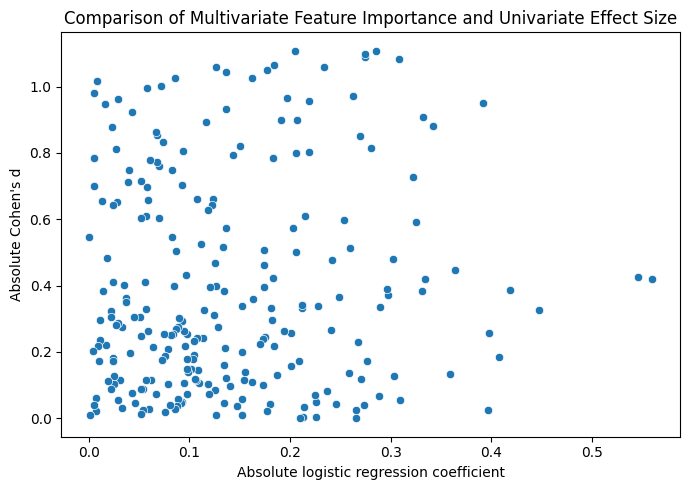

In [30]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

comparison_df = pd.merge(coef_df, effect_sizes_df, on="feature")
comparison_df = comparison_df.sort_values("abs_coefficient", ascending=False)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=comparison_df,
    x="abs_coefficient",
    y="abs_d"
)
plt.xlabel("Absolute logistic regression coefficient")
plt.ylabel("Absolute Cohen's d")
plt.title("Comparison of Multivariate Feature Importance and Univariate Effect Size")
plt.tight_layout()
plt.show()

**Figure 4.** Relationship between multivariate feature importance (logistic regression coefficients) and univariate effect sizes (Cohen’s d) across structural brain measures. The weak relationship between these measures indicates that features with large univariate group differences do not necessarily contribute most strongly to classification within the multivariate model.

### Distribution overlap for selected structural measures

To characterize overlap between groups, distributions are visualized for a small number of selected structural measures. This helps illustrate that even features contributing strongly to classification may still show substantial overlap between male and female participants.

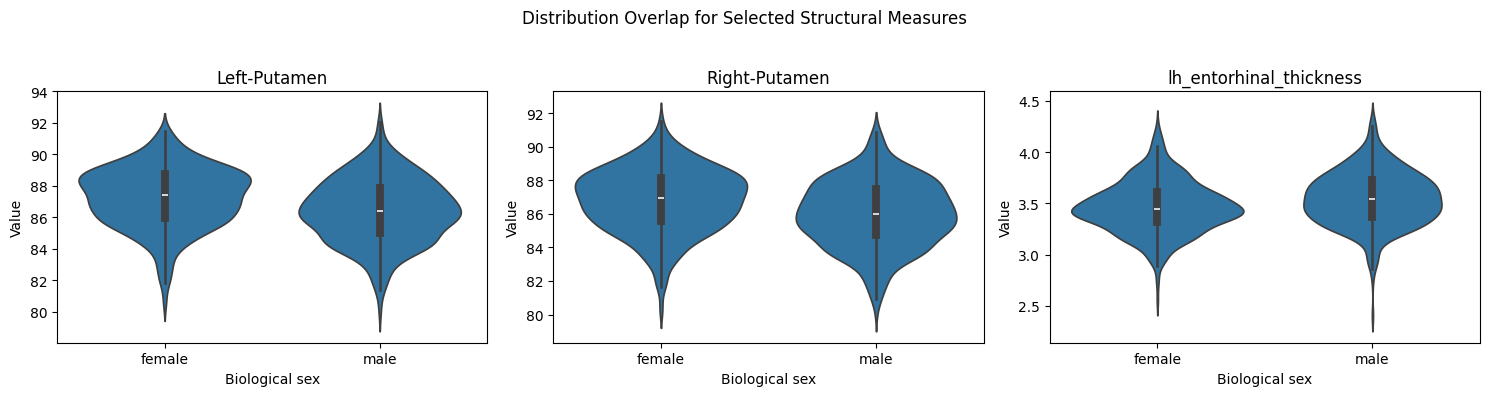

In [31]:
selected_features = top_features.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, selected_features):
    sns.violinplot(data=analysis_df, x="sex", y=feature, ax=ax, inner="box")
    ax.set_title(feature)
    ax.set_xlabel("Biological sex")
    ax.set_ylabel("Value")

plt.suptitle("Distribution Overlap for Selected Structural Measures")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Figure 5.** Distribution overlap between male and female participants for three selected structural measures. Although group differences are visible, the distributions still overlap substantially, indicating that these features do not uniquely separate the groups.

### Sensitivity analysis: controlling for global brain size

To assess whether classification performance is driven by global brain size differences, a second model is estimated including estimated total intracranial volume (eTIV) as an additional predictor.

In [36]:
# --- Sensitivity analysis: include eTIV ---

# Check that eTIV exists in data_df
assert "eTIV" in data_df.columns, "eTIV column not found in data_df"

# Create dataset including eTIV
X_with_tiv = X.copy()
X_with_tiv["eTIV"] = data_df.loc[X.index, "eTIV"]

# Train-test split (same settings as main model)
X_train_tiv, X_test_tiv, y_train_tiv, y_test_tiv = train_test_split(
    X_with_tiv,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Grid search with cross-validation
grid_search_tiv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

grid_search_tiv.fit(X_train_tiv, y_train_tiv)

# Best model
best_model_tiv = grid_search_tiv.best_estimator_

# Predictions
y_test_pred_tiv = best_model_tiv.predict(X_test_tiv)
y_test_proba_tiv = best_model_tiv.predict_proba(X_test_tiv)[:, 1]

# Evaluation
test_auc_tiv = roc_auc_score(y_test_tiv, y_test_proba_tiv)
bal_acc_tiv = balanced_accuracy_score(y_test_tiv, y_test_pred_tiv)

print("Best CV ROC-AUC with eTIV:", grid_search_tiv.best_score_)
print("Test ROC-AUC with eTIV:", test_auc_tiv)
print("Balanced accuracy with eTIV:", bal_acc_tiv)
print("Confusion matrix with eTIV:")
print(confusion_matrix(y_test_tiv, y_test_pred_tiv))

Best CV ROC-AUC with eTIV: 0.9628924674699322
Test ROC-AUC with eTIV: 0.9379126607204912
Balanced accuracy with eTIV: 0.8758832387350863
Confusion matrix with eTIV:
[[86 11]
 [12 77]]


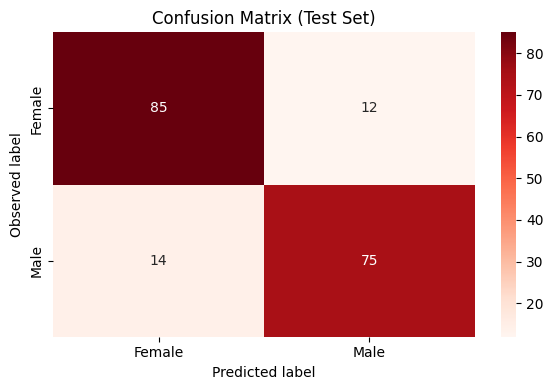

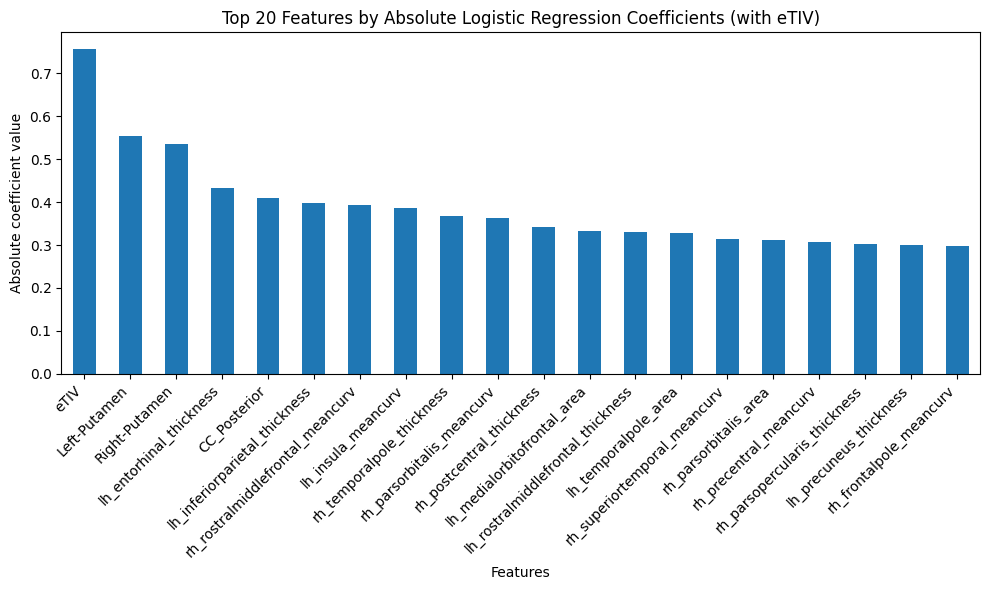

In [39]:
# Confusion matrix (already correct but fixing variable names)
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted label')
plt.ylabel('Observed label')
plt.tight_layout()
plt.show()


# Feature importance (correct pipeline extraction)

coefficients_tiv = best_model_tiv.named_steps["model"].coef_[0]

feature_importance_tiv = pd.Series(
    coefficients_tiv,
    index=X_with_tiv.columns
)

top_features_tiv = feature_importance_tiv.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_features_tiv.plot(kind='bar')
plt.title("Top 20 Features by Absolute Logistic Regression Coefficients (with eTIV)")
plt.ylabel('Absolute coefficient value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Figure 6a. Confusion matrix for the held-out test set for the model including estimated total intracranial volume (eTIV). Rows represent observed class labels and columns represent predicted class labels. Classification performance remains high, with a similar pattern of misclassifications as in the model without eTIV.

Figure 6b. Top 20 structural brain features ranked by the absolute magnitude of their standardized logistic regression coefficients in the model including eTIV. The intracranial volume measure (eTIV) emerges as the most influential feature, indicating that global brain size contributes strongly to classification, while regional features continue to provide distributed contributions.

### 3. Interpretation and Reflection (50%)

Interpretation (~400-500 words):
- What is your classification accuracy? Is this high or low, and compared to what?
- Which brain measures show the largest sex differences?
- How much overlap exists between groups? What proportion of variance is explained by sex?
- What do your results suggest about structural sex differences in the brain?

Reflection (~600-800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about neuroimaging analysis?

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings, bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*

### Interpretation

The logistic regression model achieved strong classification performance, with a test ROC–AUC of approximately 0.93 and a balanced accuracy of 0.86. Given that chance-level performance corresponds to an ROC–AUC of 0.50 and accuracy of approximately 0.50 in a balanced dataset, these results indicate that structural brain measures contain substantial information that can discriminate between male and female participants. Cross-validated performance (ROC–AUC ≈ 0.96) was consistent with test performance, suggesting good generalization and limited overfitting.

Despite this strong performance, classification was not perfect. The confusion matrix shows misclassifications in both directions, with comparable numbers of false positives and false negatives. This indicates that the model does not systematically favor one class over the other, but rather that individual brains cannot be cleanly assigned to one category based solely on structural measures. This observation is reinforced by the distribution overlap plots, which show that even features contributing strongly to classification exhibit substantial overlap between male and female participants. Thus, while group-level differences exist, individual-level variability remains considerable.

Feature importance analysis revealed that classification is driven by a distributed pattern of structural features, including subcortical volumes (e.g., putamen) and cortical measures (e.g., entorhinal thickness, temporal and frontal regions). No single region dominates classification. Univariate effect size analysis (Cohen’s d) showed moderate-to-large differences for several regions (d ≈ 0.9–1.1), indicating meaningful group differences. However, the comparison between effect sizes and logistic regression coefficients demonstrated only a weak relationship between univariate differences and multivariate importance. This suggests that features with strong group differences do not necessarily contribute most to classification when considered jointly with other variables.

The sensitivity analysis including estimated total intracranial volume (eTIV) resulted in a small increase in classification performance (ROC–AUC from 0.93 to 0.94; balanced accuracy from 0.86 to 0.88). Additionally, eTIV emerged as the most influential feature in the model. This indicates that global brain size contributes to classification performance, but does not fully account for it. Even when including eTIV, classification remains imperfect and substantial overlap persists.

Overall, these findings suggest that structural sex differences in the brain are best understood as distributed statistical tendencies rather than discrete, clearly separable categories. While multivariate models can exploit subtle patterns across many regions to achieve high classification accuracy, individual variation remains large, and no single feature uniquely determines group membership.

### Reflection

A central challenge encountered during this project was understanding the relationship between model performance and interpretability, particularly in the context of high-dimensional neuroimaging data. Initially, the modelling process appeared straightforward: logistic regression with cross-validation produced strong classification results, suggesting that structural brain measures could reliably distinguish between sexes. However, as the analysis progressed, it became clear that high predictive performance does not necessarily translate into clear or meaningful biological interpretation.

One of the most important challenges was identifying the role of global brain size in the model. In early iterations, the intracranial volume measure (eTIV) was implicitly included among the predictors. This resulted in very strong classification performance and cleaner separation between groups. However, further inspection revealed that eTIV was acting as a dominant feature, raising concerns that the model might be capturing overall size differences rather than region-specific structural variation. This prompted a revision of the feature selection process, explicitly excluding intracranial volume from the main model and reserving it for a sensitivity analysis.

This adjustment led to noticeable changes in the results. Without eTIV, classification performance decreased slightly, and visualizations such as overlap plots appeared less separable than initially expected. At first, this seemed counterintuitive, as the expectation was that structural differences between sexes would be more clearly visible. However, this shift ultimately clarified an important insight: apparent separability in earlier results was partly driven by global brain size, and removing this factor revealed the underlying variability and overlap between individuals. Including eTIV in a secondary model confirmed this interpretation, as performance improved modestly but not dramatically, indicating that global size contributes to (but does not fully explain) the classification signal.

Another challenge involved understanding the relationship between univariate and multivariate analyses. While Cohen’s d values suggested moderate-to-large differences for several brain regions, the comparison with logistic regression coefficients showed that these features were not always the most influential in the classification model. This highlighted the importance of considering multivariate relationships and collinearity, as features that appear important in isolation may be redundant or less informative when considered jointly. This distinction was not immediately intuitive and required careful interpretation of both statistical measures.

A further practical challenge was managing the workflow in a notebook environment. At several points, inconsistent results were produced due to stale variables or partial re-execution of cells. This required restarting the runtime and ensuring that all steps were executed sequentially. This experience emphasized the importance of reproducibility and careful control of computational state, particularly when working with iterative analyses.

The main limitation of this approach is that it relies on a relatively simple linear model and a predefined set of structural features. Logistic regression assumes linear relationships and may not capture more complex patterns in the data. Additionally, although the dataset is relatively large for neuroimaging, it remains moderate in size compared to the number of features, which may affect stability. Another limitation is that the analysis is restricted to structural MRI measures and a binary definition of biological sex, which simplifies the complexity of both brain organization and biological variation.

Overall, this project provided valuable insight into the distinction between predictive modelling and scientific explanation. It demonstrated that strong classification performance can arise from distributed and overlapping patterns rather than clear-cut differences, and that careful feature selection is essential for meaningful interpretation. It also highlighted the importance of critically evaluating model outputs rather than taking performance metrics at face value. These lessons are central to neuroimaging analysis and will inform future work involving high-dimensional biological data.